# Exploring Ground Motion Models and Random Effects Residuals for Southern Italy using eGSIM

In this Jupyter notebook we are going to take the flatfile that was built in the previous notebook (`EFEHR_Services_Demo/ESM and eGSIM - Data Download and Flatfile Preparation.ipynb`) and use eGSIM to explore the distribution of random-effects residuals of the data against selected ground motion models. 

This workflow provides an illustration of a process for identifying potential GMMs for use in Southern Italy and then exploring in greater depths how the between-event residuals ($\delta B_e$), the station-to-station residuals ($\delta S2S_S$) and the within-event residuals ($\delta W_{ES}$) scale with different predictor variables. This can help show which GMMs may provide "better" or "worse" fits to data overall before then delving into details to identify potential biases or outlier regions.

The notebook comprises the following steps:

1) Use the eGSIM API to retrieve various model-to-data fitting metrics (e.g. mean/std of the residuals, log-likelihood, empirical distance range) and their variation with period.

2) Retreive the normalized between-event and within-event residuals for our data set using the API and explore their variation with different predictor variables.

3) Determine $\delta S2S_S$ from the non-normalized residuals and show how this compares with $V_{S30}$ and varies spatially.

The main libraries we are using are: Numpy, Scipy, Pandas, Matplotlib and GeoPandas.

N.B. Note that if you want to download the data in hdf5 format (recommended) and read the table in Pandas then you will need to have the Pytables library installed.


In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline
import requests  # To make the eGSIM API request
from typing import List, Dict
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LogNorm

### Driving the eGSIM API

Below is a function that builds and executes the eGSIM API query for the model-to-data comparisons. It requires the following as inputs:

`flatfile_path`: The path to the csv flatfile that was created at the end of the previous notebook.

`gmms`: The list of selected GMMs according to their [OpenQuake Class names](https://docs.openquake.org/oq-engine/master/manual/api-reference/openquake.hazardlib.gsim.html)

`imts`: The list of selected intensity measure types (e.g. PGV, PGA, SA(1.0) etc.) as strings, e.g. `["PGV", "PGA", "SA(1.0

`data_format`: Download the data in either `csv` or `hdf` (recommended, default)

`query_string`: A string representing a Pandas query of the flatfile, e.g. `"(mag >= 4.0) & (rrup <= 300)"`

`normalize`: Return the residuals normalized by the GMM standard deviations (`True`, default) or not (`False`).

`likelihood`: Return the likelihood values (`True`) or not (`False` default).

`ranking`: Returns the full suite of scoring metrics (`True`) or not (`False`, default)

The function will return a pandas Dataframe with all the required information.

In [3]:
def get_residuals_from_egsim(
    flatfile_path: str,
    gmms: List,
    imts: List,
    data_format: str = "hdf",
    query_string: str = "",
    normalize: bool = True,
    likelihood: bool = False,
    ranking: bool = False
) -> pd.DataFrame:
    """Retreive the residuals for the flatfile and the selected
    set of ground motion models and intensity measure types

    Args:
        flatfile_path: Local path to the selected flatfile
        gmms: List of ground motion models (OpenQuake class names)
        imts: List of intensity measure types (e.g. PGA, PGV, SA(0.1) etc.)
        plot_type: Column to return for x-values (e.g. mag, rrup, etc)
        query_string: Selection query to apply to the data

    Returns:
        dframe: The dataframe containing the query results
    """
    assert data_format in ("hdf", "csv"), "Data format must be either 'hdf' or 'csv'"
    # Set the eGSIM URL to get the ground motion residuals
    egsim_url_residuals = "https://egsim.gfz.de/api/query/residuals"
    # Retreive residuals for a given plot type
    parameters = {
            "model": gmms,
            "imt": imts,
            "format": data_format      
    }
    if query_string:
        parameters["data-query"] = query_string
    if not normalize:
        parameters["normalize"] = False
    if likelihood:
        parameters["likelihood"] = True
    if ranking:
        parameters["ranking"] = True

    with open(flatfile_path, "rb") as flatfile:
        files = {"flatfile": flatfile}
        try:
            # POST request for eGSIM
            response = requests.post(
                egsim_url_residuals,
                files=files,
                data=parameters
            )
            print(response.status_code)
            response.raise_for_status()
        except requests.exceptions.HTTPError as exc:
            code = exc.response.status_code
            print(response.text)
        except:
            print("Response failed - see status message")
            raise  
    
    if parameters['format'] == 'hdf':
        # `pd.read_hdf` works for HDF files on disk. Workaround:
        with pd.HDFStore(
                "data.h5",  # apparently unused for in-memory data
                mode="r",
                driver="H5FD_CORE",  # create in-memory file
                driver_core_backing_store=0,  # for safety, just in case
                driver_core_image=response.content) as store:
            dframe = store[list(store.keys())[0]]
    else:
        # use `pd.read_csv` with a BytesIO (file-like object) as input: 
        dframe = pd.read_csv(io.BytesIO(response.content), header=[0, 1, 2], index_col=0)        

    return dframe

Load in the data we will use for our basemap!

(36.0, 41.0)

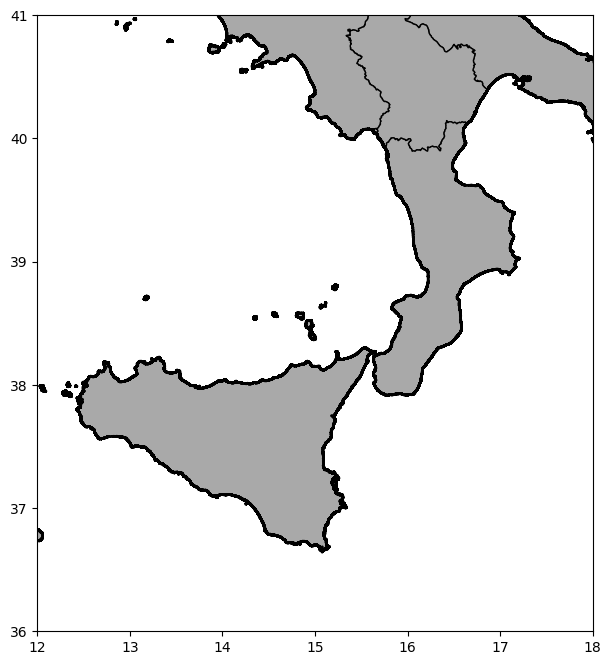

In [4]:
ita0 = gpd.read_file("./data/gadm40_ITA_shp/gadm40_ITA_0.shp")
ita1 = gpd.read_file("./data/gadm40_ITA_shp/gadm40_ITA_1.shp")
w, s, e, n = bbox = (12.0, 36.0, 18.0, 41.0)
fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
ax.set_xlim(w, e)
ax.set_ylim(s, n)

## Measuring the "Overall" Fit of Different GMMs to data

One of the first and simplest steps to take when considering which GMMs to use in a region is to look at metrics that describe the overall fit of the model to data. There are several such metrics in the literature, several of which are returned by the eGSIM API:

`loglikelihood`: Log-likelihood metric of Scherbaum et al (2009) (https://doi.org/10.1785/0120080347) - lower log-likehood scores indicate a smaller model distance between observations and the model

`total_residual`, `inter_event_residual` and `intra_event_residual` mean and standard deviation: These indicate systematic over- or underprediction of the median ground motion or its variability. For the normalised residuals a mean close to 0 and standard deviation close to 1 would indicate a strong fit to the data.

`EDR`: Euclidean Distance Ranking metric by Kale & Akkar (2013) (https://doi.org/10.1785/0120120134) - similar to the log-likelhood a lower EDR indicates a lower model distance between a model and the observations

Many of the metrics can be assessed on an intensity-measure by intensity-measure (or period-by-period) basis, which can be helpful to understand whether there is period-dependence in the overall fit, or else a single score can be determined for each model.

Below we show how to retrieve the ranking metrics for the flatfile and plot the variation with period

In [5]:
# Define the set of periods
periods = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 2.0, 3.0]
# Create the full list of intensity measures inclusing PGV and PGA
imts = ['PGV', 'PGA'] + [f"SA({per})" for per in periods]

# Choose our four GMMs - here we will assign each GMM a "pretty name" and a colour (for plotting)
gmms = {
    # OpenQuake Class Name: (Pretty name, plotting colour)
    "BooreEtAl2014": ("Boore et al. (2014)", "tab:red"),
    "CauzziEtAl2014": ("Cauzzi et al. (2015)", "tab:blue"),
    "LanzanoEtAl2019_RJB_OMO": ("Lanzano et al. (2019)", "tab:green"),
    "KothaEtAl2020ESHM20": ("ESHM20", "k"),
}

# Limit our comparisons to magnitudes greater than 4, rupture distances < 300 and depths less than 35 km
query_string = "(rrup <= 300.0) & (mag >= 4.0) & (evt_depth <= 35.0)" # & (vs30measured == True)"


In [6]:
# This may take a minute or so
rankings = get_residuals_from_egsim(
    "./SItaly_egsim_flatfile.csv",  # Path to the flatfile
    gmms=list(gmms),  # List of GMMS
    imts=imts,  # List of IMTs
    query_string=query_string,  # The executed query string
    ranking=True  # Choose to return the ranking (scoring) metrics rather than residuals
)
rankings

200


,PGA total_residual mean,PGA total_residual stddev,PGA inter_event_residual mean,PGA inter_event_residual stddev,PGA intra_event_residual mean,PGA intra_event_residual stddev,PGV total_residual mean,PGV total_residual stddev,PGV inter_event_residual mean,PGV inter_event_residual stddev,...,SA(0.3) loglikelihood,SA(0.5) loglikelihood,SA(0.75) loglikelihood,SA(1.0) loglikelihood,SA(2.0) loglikelihood,SA(3.0) loglikelihood,All_IMT loglikelihood,mde_norm,sqrt_kappa,edr
BooreEtAl2014,-0.866467,1.573675,-1.036539,1.500497,-0.072288,1.235658,-0.376184,1.370627,-0.329373,1.152447,...,3.218849,2.878229,2.691806,2.644616,2.644194,2.517589,3.126804,1.629675,1.101629,1.795297
CauzziEtAl2014,-1.411601,1.612337,-1.688622,1.344355,-0.088222,1.424335,-0.886578,1.465050,-0.897650,1.159254,...,3.260403,2.582817,2.359530,2.289684,2.254449,2.253133,3.399724,1.780380,1.161538,2.067979
KothaEtAl2020ESHM20,-0.779910,1.503894,-0.804366,1.339113,-0.043806,1.240746,-0.431577,1.433915,-0.348649,1.277935,...,2.951717,2.574971,2.414755,2.379899,2.388058,2.450725,2.953467,1.570521,1.123564,1.764581
LanzanoEtAl2019_RJB_OMO,-0.487718,1.587120,-0.324416,1.486798,-0.028963,1.205334,-0.266192,1.538510,-0.039845,1.344062,...,2.976926,2.794397,2.591411,2.524895,2.507435,2.451900,2.943124,1.539472,1.082693,1.666775


The query returns a lot of results for each GMM. View the full list of headers ...

In [78]:
rankings.columns.to_list()

['PGA total_residual mean',
 'PGA total_residual stddev',
 'PGA inter_event_residual mean',
 'PGA inter_event_residual stddev',
 'PGA intra_event_residual mean',
 'PGA intra_event_residual stddev',
 'PGV total_residual mean',
 'PGV total_residual stddev',
 'PGV inter_event_residual mean',
 'PGV inter_event_residual stddev',
 'PGV intra_event_residual mean',
 'PGV intra_event_residual stddev',
 'SA(0.01) total_residual mean',
 'SA(0.01) total_residual stddev',
 'SA(0.01) inter_event_residual mean',
 'SA(0.01) inter_event_residual stddev',
 'SA(0.01) intra_event_residual mean',
 'SA(0.01) intra_event_residual stddev',
 'SA(0.05) total_residual mean',
 'SA(0.05) total_residual stddev',
 'SA(0.05) inter_event_residual mean',
 'SA(0.05) inter_event_residual stddev',
 'SA(0.05) intra_event_residual mean',
 'SA(0.05) intra_event_residual stddev',
 'SA(0.1) total_residual mean',
 'SA(0.1) total_residual stddev',
 'SA(0.1) inter_event_residual mean',
 'SA(0.1) inter_event_residual stddev',
 'SA

#### Now create a plot that shows the variations in all these metrics with period.

First sort out the relevant results by category

In [7]:
# First, select the columns and extract the spectral period (if SA) or assign a period for plotting (PGV, PGA)
column_set = {
    "loglikelihood": [],
    "total_residual mean": [],
    "total_residual stddev": [],
    "inter_event_residual mean": [],
    "inter_event_residual stddev": [],
    "intra_event_residual mean": [],
    "intra_event_residual stddev": [],
}

periods = []
for i_m in imts:
    for key in column_set:
        if i_m.startswith("SA("):
            period = f"SA({float(i_m.replace("SA(", "").replace(")", ""))})"
            column_set[key].append(f"{period} {key}")
        else:
            column_set[key].append(f"{i_m} {key}")
    if i_m == "PGV":
        periods.append(0.003)
    elif i_m == "PGA":
        periods.append(0.006)
    else:
        period = float(i_m.replace("SA(", "").replace(")", ""))
        periods.append(period)


Then make the plots

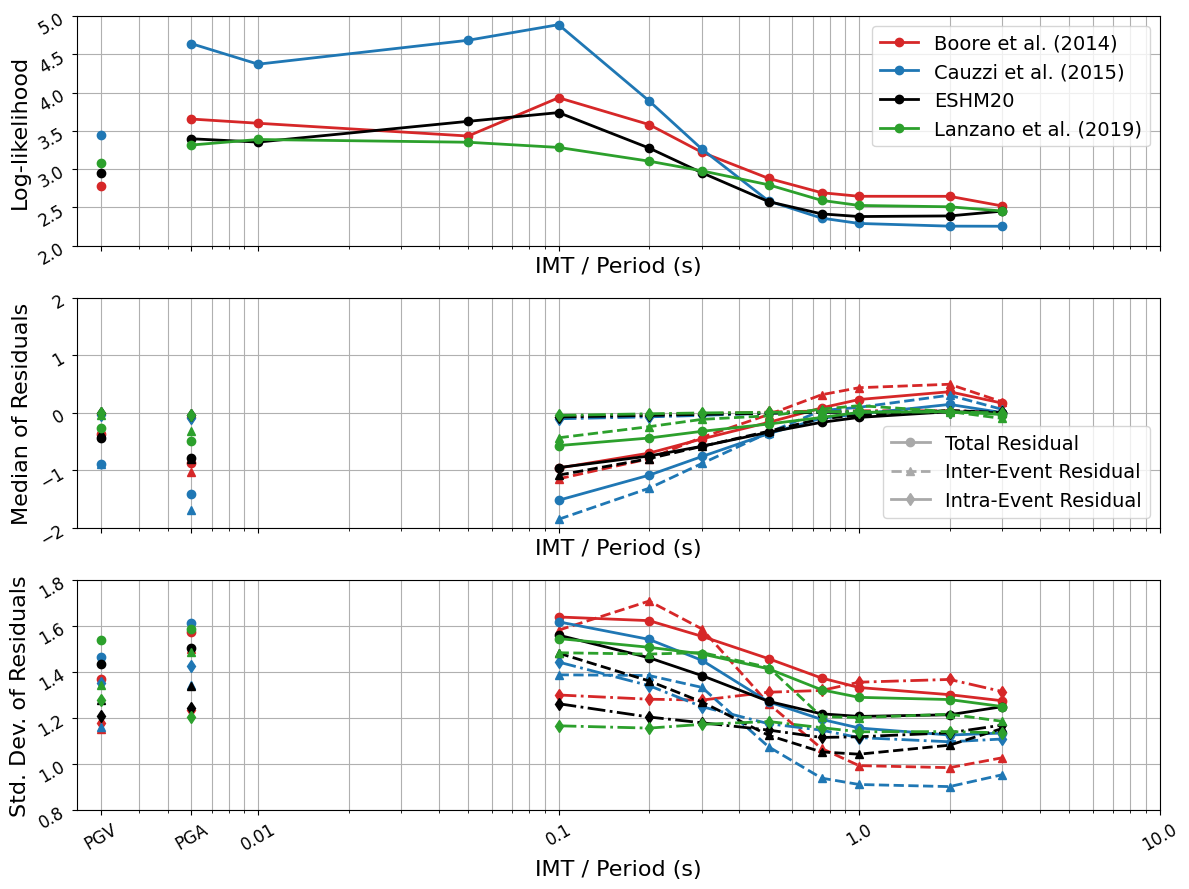

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(12,9), sharex=True)
for gmm in rankings.index:
    gmm_name, gmm_color = gmms[gmm]
    # Loglikelihood
    axs[0].plot(
        periods[0],
        rankings[column_set["loglikelihood"]].loc[gmm].to_numpy()[0],
        "o", color=gmm_color, lw=2
    )
    axs[0].plot(
        periods[1:],
        rankings[column_set["loglikelihood"]].loc[gmm].to_numpy()[1:],
        "o-", color=gmm_color, lw=2,
        label=gmm_name
    )
    for key, lstyle, mkr in zip(["total_residual", "inter_event_residual", "intra_event_residual"],
                                 ["-", "--", "-."], ["o", "^", "d"]):
        # Show the trends in the mean residuals
        axs[1].plot(
            periods[0],
            rankings[column_set[f"{key} mean"]].loc[gmm].to_numpy()[0],
            ls=lstyle, marker=mkr, color=gmm_color, lw=2
        )
        axs[1].plot(
            periods[1:],
            rankings[column_set[f"{key} mean"]].loc[gmm].to_numpy()[1:],
            ls=lstyle, marker=mkr, color=gmm_color, lw=2
        )
        # Show the trends in the standard deviations of the residuals
        axs[2].plot(
            periods[0],
            rankings[column_set[f"{key} stddev"]].loc[gmm].to_numpy()[0],
            ls=lstyle, marker=mkr, color=gmm_color, lw=2
        )
        axs[2].plot(
            periods[1:],
            rankings[column_set[f"{key} stddev"]].loc[gmm].to_numpy()[1:],
            ls=lstyle, marker=mkr, color=gmm_color, lw=2
        )

# Create elements for legend
residual_stats_lines = [
    Line2D([0], [0], color="darkgrey", lw=2, marker="o", label="Total Residual"),
    Line2D([0], [0], color="darkgrey", lw=2, ls="--", marker="^", label="Inter-Event Residual"),
    Line2D([0], [0], color="darkgrey", lw=2, ls="-", marker="d", label="Intra-Event Residual"),
]
    
axs[0].legend(loc="upper right", fontsize=14)
axs[1].legend(loc="lower right", handles=residual_stats_lines, fontsize=14)
axs[0].set_ylabel("Log-likelihood", fontsize=16)
axs[0].set_ylim(2.0, 5.0)
axs[1].set_ylabel(r"Median of Residuals", fontsize=16)
axs[1].set_ylim(-2.0, 2.0)
axs[2].set_ylabel(r"Std. Dev. of Residuals", fontsize=16)
axs[2].set_ylim(0.8, 1.8)
for ax in axs:
    ax.grid(which="both")
    ax.set_xscale("log")
    ax.set_xlabel("IMT / Period (s)", fontsize=16)
    #ax.set_ylabel()
    ax.set_xlim(0.0025, 10.0)
    ax.set_xticks([0.003, 0.006, 0.01, 0.1, 1.0, 10.0], ["PGV", "PGA", "0.01", "0.1", "1.0", "10.0"])
    ax.tick_params(labelsize=12, labelrotation=30)
fig.tight_layout()

So what can be interpreted from this plot:

1) All the models give higher log-likelihoods at shorter periods, reducing with period. This implies poorer fit to data at shorter periods. Generally the Lanzano et al. (2019) model gives the lowest LLH values across the broadest range, followed closely by the ESHM20 model. The Cauzzi et al. (2015) model fits very poorly to the shorter period ground motions, but then particularly well for the longer periods.
   
2) The residuals are typically biased negative at shorter periods, implying that the models are systematically predicting higher ground motions than the observations. Here we see that the negative residuals are apparent in the between-event residuals, while the intra-event residuals are largely unbiased (close to 0). Once again, the bias is less for the Lanzano et al. (2019) model.

3) The standard deviation of the residuals is higher than 1 for most models over most periods (except Cauzzi et al., 2015 at longer periods). This indicates that the variability in the observations is higher than that predicted by the model.

# Comparing Observations against GMMs - Random Effects Residuals

Analysis such as the log-likelihood above can give a first-order overview of which GMMs are fitting the data better or worse (among those selected). But they do not provide insight into _exactly_ where the model and the data are matching well, and where there are potential biases and divergences. This is important because knowing where there is systematic bias in the data can help hazard modellers understand whether adjustments to the model might be needed, and are the spatial (or even temporal) variations that be critical for seismic hazard analysis.

What are random effects residuals?

A ground motion model generally takes the following form:

$\ln Y_{es} = f\left( {M_e, R_{es}, \bar{S}, \mathbf{\theta}} \right) + \delta_{es}$ 

where $Y$ is the ground motion intensity recorded as site $s$ from earthquake $e$. $f\left( {M_e, R_{es}, \bar{S}, \mathbf{\theta}} \right)$ is the expected (median) ground motion and $\delta_{es}$ the _total_ residual (i.e. the difference between the prediction and observation. When a ground motion model is fit to a set of data, the total residual is normally distributed with a mean of 0 and a standard deviation of $\sigma_T$.

Ground motion databases such as those used here have records from many events. For each events the ground motions may be systematically higher or lower than the median expected by the model, indicating that the event is more or less energetic for the same scenarios than the centre of the distribution described by the model. We can therefore separate the total residual into a _between-event_ (or _inter-event_) residual and a _within-event_ (or _intra-event_) residual term.

$\ln Y_{es} = f\left( {M_e, R_{es}, \bar{S}, \mathbf{\theta}} \right) + \delta B_e + \delta W_{es}$ 

The between-event and within-event residuals are normally distributed with means of 0 and standard deviations of $\tau$ and $\phi$ respectively. The standard deviation is the square-root of the sum of squares of the between- and within-event standard deviations:

$\sigma_T = \sqrt{\tau^2 + \phi^2}$

When comparing GMMs against data it is often preferable to look at the trends in the residuals _normalized_ with respect to the $\sigma_T$, $\tau$ and $\phi$ of the GMM, i.e. $\frac{\delta_{es}}{\sigma_T}$, $\frac{\delta B_e}{\tau}$ and $\frac{\delta W_{es}}{\phi}$ respectively. For a perfectly unbiased GMM the distribution of the normalized residuals should be the standard normal distribution with mean of 0 and standard deviation of 1.0.

However, the non-normalized residuals can also be important if one wishes to delve deeper into the structure of the variance and its spatial variation - this is critical for non-ergodic modelling. Fortunately eGSIM can help with this too.

In this example we will show to how to get the random effects residuals using eGSIM


To get the residuals we can just call the function defined above for the same GMMs and IMTs. 

We will limit here our records to just those from magnitudes > 3.5, rupture distances <= 300 and hypocentral depths <= 35 km

In [15]:
residuals_observations = get_residuals_from_egsim(
    "./SItaly_egsim_flatfile.csv",  # Path to the flatfile
    gmms=list(gmms),  #
    imts=imts,
    query_string="(rrup <= 300.0) & (mag >= 3.5) & (evt_depth <= 35.0)",
    normalize=True,
)
residuals_observations

200


,PGA total_residual BooreEtAl2014,PGA total_residual CauzziEtAl2014,PGA total_residual KothaEtAl2020ESHM20,PGA total_residual LanzanoEtAl2019_RJB_OMO,PGA inter_event_residual BooreEtAl2014,PGA inter_event_residual CauzziEtAl2014,PGA inter_event_residual KothaEtAl2020ESHM20,PGA inter_event_residual LanzanoEtAl2019_RJB_OMO,PGA intra_event_residual BooreEtAl2014,PGA intra_event_residual CauzziEtAl2014,...,input intensity_measure SA(3.0),input rupture_parameter evt_id,input rupture_parameter hypo_depth,input rupture_parameter mag,input rupture_parameter rake,input site_parameter region,input site_parameter station_latitude,input site_parameter station_longitude,input site_parameter vs30,input site_parameter vs30measured
352,-1.060915,-2.186402,-0.806267,-0.045518,-1.873232,-2.820867,-1.743508,-1.425077,-0.215531,-0.492851,...,2.718058e-06,EMSC-20110506_0000042,20.35,4.3,146.0,0,39.2534,16.2114,620.0,False
353,-2.235241,-2.586629,-2.151246,-2.492376,-1.972621,-2.820867,-1.743508,-1.425077,-1.446165,-1.014277,...,9.618348e-05,EMSC-20110506_0000042,20.35,4.3,146.0,0,37.6863,14.9129,592.0,False
354,-1.690307,-2.319889,-1.659713,-1.727895,-1.972621,-2.820867,-1.743508,-1.425077,-0.818203,-0.666761,...,3.161498e-05,EMSC-20110506_0000042,20.35,4.3,146.0,0,37.6314,15.0216,546.0,False
355,-1.675401,-2.330088,-1.650736,-1.697221,-1.972621,-2.820867,-1.743508,-1.425077,-0.801026,-0.680049,...,5.259638e-05,EMSC-20110506_0000042,20.35,4.3,146.0,0,37.6892,15.1356,554.0,False
356,-0.838299,-1.791767,-0.783566,-0.278669,-1.972621,-2.820867,-1.743508,-1.425077,0.163619,0.021292,...,2.592665e-05,EMSC-20110506_0000042,20.35,4.3,146.0,0,37.1783,14.7155,872.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,-2.265759,-3.392316,-2.239066,-1.776448,-1.898107,-2.644855,-1.947908,-1.777193,-1.564718,-2.210934,...,4.637239e-07,IT-2013-0018,9.65,4.0,0.0,0,39.8772,16.3459,845.0,False
623,-2.709932,-3.606214,-2.644016,-2.321540,-1.921035,-2.644855,-1.947908,-1.777193,-2.033970,-2.489608,...,1.450606e-06,IT-2013-0018,9.65,4.0,0.0,0,39.0359,16.6886,923.0,False
624,-0.090221,-1.209706,-0.623228,-0.451057,-1.933422,-2.644855,-1.947908,-1.777193,1.003230,0.632632,...,1.256767e-05,IT-2013-0018,9.65,4.0,0.0,0,38.2603,15.8939,1125.0,False
625,-1.502445,-2.697513,-1.625998,-1.025851,-1.897358,-2.644855,-1.947908,-1.777193,-0.705049,-1.305725,...,6.425153e-07,IT-2013-0018,9.65,4.0,0.0,0,39.9938,15.8155,1227.0,False


The the table provides a lot of information, which includes:

1) The total, inter- and intra-event residual for each IMT and GMM (header structure is always `IMT residual_type GMM`)
2) The intensity measure values `input intensity_measure IMT`
3) The input distance metrics `input distance_measure dist_type`
4) The input rupture information `input rupture_parameter rupt_param`
5) The input site information `input site_parameter site_param`

View all the columns

In [10]:
residuals_observations.columns.to_list()

['PGA total_residual BooreEtAl2014',
 'PGA total_residual CauzziEtAl2014',
 'PGA total_residual KothaEtAl2020ESHM20',
 'PGA total_residual LanzanoEtAl2019_RJB_OMO',
 'PGA inter_event_residual BooreEtAl2014',
 'PGA inter_event_residual CauzziEtAl2014',
 'PGA inter_event_residual KothaEtAl2020ESHM20',
 'PGA inter_event_residual LanzanoEtAl2019_RJB_OMO',
 'PGA intra_event_residual BooreEtAl2014',
 'PGA intra_event_residual CauzziEtAl2014',
 'PGA intra_event_residual KothaEtAl2020ESHM20',
 'PGA intra_event_residual LanzanoEtAl2019_RJB_OMO',
 'PGV total_residual BooreEtAl2014',
 'PGV total_residual CauzziEtAl2014',
 'PGV total_residual KothaEtAl2020ESHM20',
 'PGV total_residual LanzanoEtAl2019_RJB_OMO',
 'PGV inter_event_residual BooreEtAl2014',
 'PGV inter_event_residual CauzziEtAl2014',
 'PGV inter_event_residual KothaEtAl2020ESHM20',
 'PGV inter_event_residual LanzanoEtAl2019_RJB_OMO',
 'PGV intra_event_residual BooreEtAl2014',
 'PGV intra_event_residual CauzziEtAl2014',
 'PGV intra_even

From this we can visualize trends in the random effects residuals (as we did on the platform)

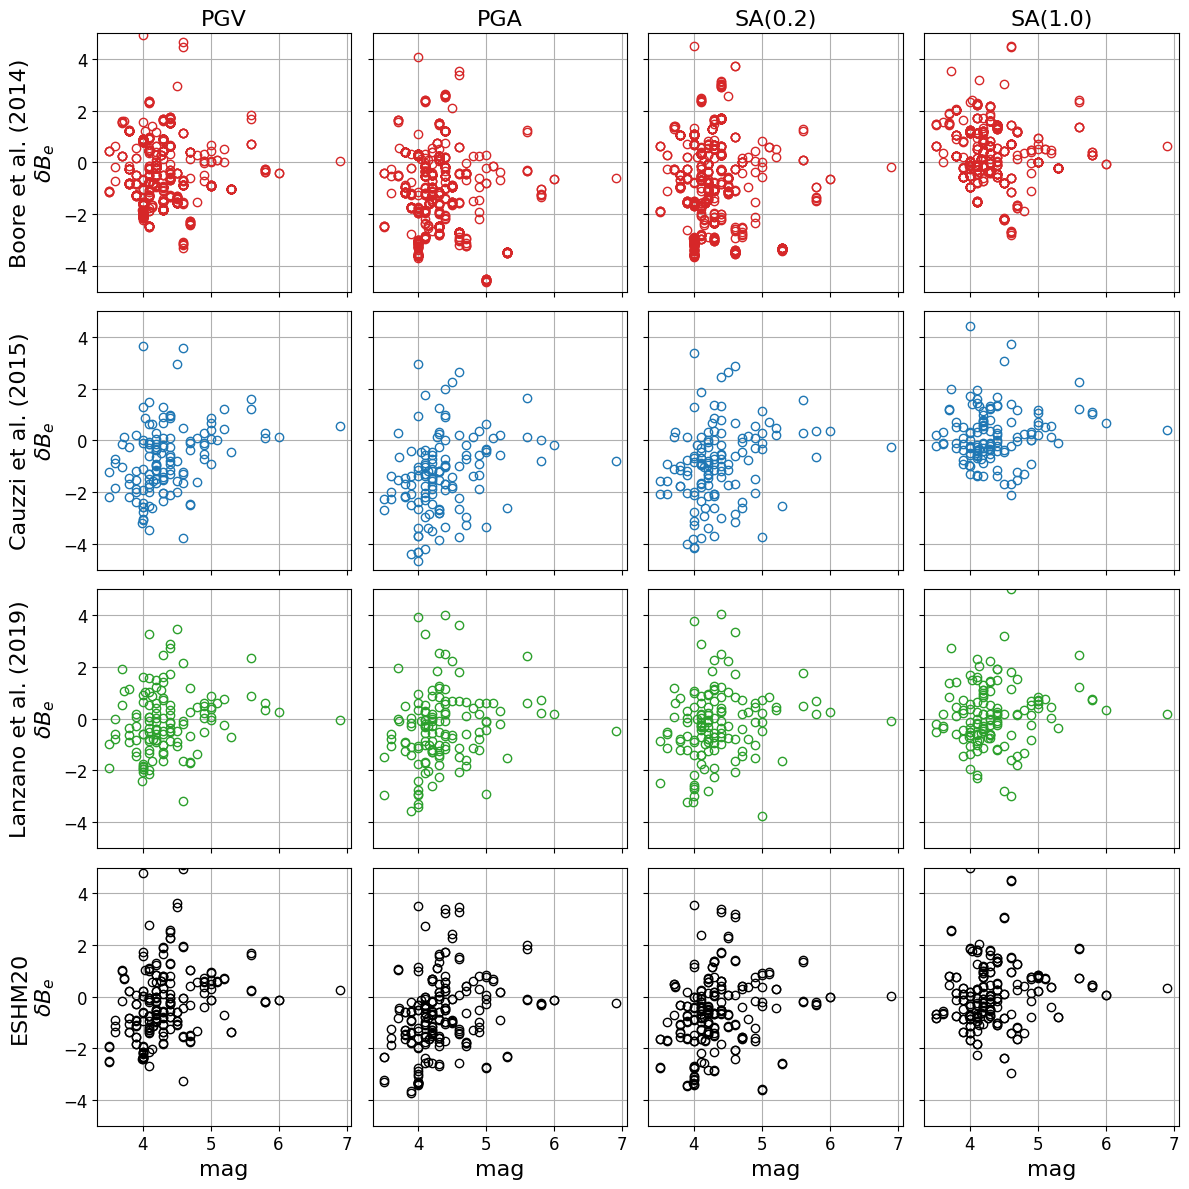

In [11]:
selected_imts = ["PGV", "PGA", "SA(0.2)", "SA(1.0)"]
fig, axs = plt.subplots(4, 4, figsize=(12,12), sharex=True, sharey=True)
predictor = "input rupture_parameter mag"  # Choose the predictor to plot against
for i, imt in enumerate(selected_imts):
    for j, gmm in enumerate(list(gmms)):
        gmm_id, gmm_col = gmms[gmm]
        predictand =  f"{imt} inter_event_residual {gmm}"
        xyvals = residuals_observations[[predictor, predictand]].copy()
        xyvals.drop_duplicates(inplace=True)
        axs[j, i].plot(xyvals[predictor], xyvals[predictand], "o", mec=gmm_col, mfc="None")
        axs[j, i].set_ylim(-5.0, 5.0)
        axs[j, i].grid(which="both")
        axs[j, i].tick_params(labelsize=12)
for i in range(4):
    gmm_id = gmms[list(gmms)[i]][0]
    axs[0, i].set_title(selected_imts[i], fontsize=16)
    axs[-1, i].set_xlabel(predictor.split()[-1], fontsize=16)
    axs[i, 0].set_ylabel(gmm_id + "\n" + r"$\delta B_e$" , fontsize=16)
fig.tight_layout()

The figure above provides a little further insights into the cause of the discrepancies. While the number of records from larger (M ≥ 4.5) events is limited, it seems that it is magnitudes in the range 3.5 ≤ M ≤ 4.5 where we see the systematically negative residuals at short periods. 

How can we identify the cause of this?

One issue is that when we compiled the flatfile we chose to take each magnitude as reported and not convert from the originally reported scale to a harmonised moment magnitude scale. For large events most earthquakes had a moment magnitude, but for smaller earthquakes this is less routinely calculated and systematic biases between the magnitudes can be present.

Can we separate out the between event-residuals by different magnitude type?

### Adding further information from the flatfile

The eGSIM API query returns only the fields that were used by the GMMs, but not all the fields in the flatfile - this keeps the data transfer and handling manageable!

_However_ the index of the dataframe returned by the eGSIM is aligned with that of the _input flatfile_ (albeit re-ordered). This makes it easy to add on additional fields to the results dataframe from the flatfile.

Let's load in the file directly and execute the same query on it that was passed to the eGSIM API

In [12]:
flatfile = pd.read_csv("./SItaly_egsim_flatfile.csv", sep=",")
flatfile.query(
    "(rrup <= 300.0) & (mag >= 3.5) & (evt_depth <= 35.0)",
    inplace=True
)
flatfile

,wfid,evt_id,site_id,evt_datetime,evt_longitude,evt_latitude,evt_depth,mag,mag_type,strike,...,SA(5.50000),SA(6.00000),SA(6.50000),SA(7.00000),SA(7.50000),SA(8.00000),SA(8.50000),SA(9.00000),SA(9.50000),SA(10.00000)
0,IT-1978-0002|IT.FRR..HN,IT-1978-0002,IT.FRR..HN,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,5.2,mw,66.0,...,5.555817e-04,4.535722e-04,3.754978e-04,3.148659e-04,2.733374e-04,2.403810e-04,2.130161e-04,1.900329e-04,1.705899e-04,1.538506e-04
1,IT-1978-0002|IT.PLL..HN,IT-1978-0002,IT.PLL..HN,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,5.2,mw,66.0,...,6.817968e-04,5.379185e-04,4.351520e-04,3.544028e-04,2.941618e-04,2.424509e-04,1.994857e-04,1.688960e-04,1.458347e-04,1.248412e-04
2,IT-1978-0002|IT.VLS2..HN,IT-1978-0002,IT.VLS2..HN,1978-03-11T19:20:49.000000,15.9121,38.0787,23.5328,5.2,mw,66.0,...,3.077752e-04,2.576518e-04,2.197970e-04,1.897224e-04,1.651458e-04,1.447041e-04,1.275284e-04,1.131041e-04,1.008337e-04,9.026502e-05
5,IT-1978-0004|IT.GRR..HN,IT-1978-0004,IT.GRR..HN,1978-04-15T23:33:47.000000,15.1100,38.2700,22.0000,6.0,mw,147.0,...,6.048856e-04,5.290585e-04,4.619737e-04,4.020876e-04,3.484949e-04,3.006390e-04,2.583994e-04,2.231369e-04,1.931826e-04,1.678263e-04
6,IT-1978-0004|IT.MLZ..HN,IT-1978-0004,IT.MLZ..HN,1978-04-15T23:33:47.000000,15.1100,38.2700,22.0000,6.0,mw,147.0,...,8.202239e-04,6.763319e-04,5.653779e-04,4.781884e-04,4.090800e-04,3.526070e-04,3.064148e-04,2.688195e-04,2.373065e-04,2.104016e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3106,INT-20251215_0000143|IV.HLNI..HN,INT-20251215_0000143,IV.HLNI..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3000,4.1,ml,0.0,...,4.495737e-07,3.447793e-07,3.077165e-07,2.484061e-07,2.174975e-07,1.957324e-07,1.685871e-07,1.441962e-07,1.338281e-07,1.213669e-07
3107,INT-20251215_0000143|IV.HMDC..HN,INT-20251215_0000143,IV.HMDC..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3000,4.1,ml,0.0,...,8.722925e-07,8.527594e-07,6.482460e-07,5.802435e-07,4.447923e-07,3.785775e-07,3.523655e-07,2.768963e-07,2.149587e-07,2.072002e-07
3108,INT-20251215_0000143|IV.IPAI..HN,INT-20251215_0000143,IV.IPAI..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3000,4.1,ml,0.0,...,2.228707e-07,2.062699e-07,1.730371e-07,1.395210e-07,1.158036e-07,1.052343e-07,9.722776e-08,8.484079e-08,7.473917e-08,6.694094e-08
3109,INT-20251215_0000143|IV.ISPIC..HN,INT-20251215_0000143,IV.ISPIC..HN,2025-12-15T09:11:21.000000,16.8691,36.5346,24.3000,4.1,ml,0.0,...,4.425318e-07,3.297761e-07,2.670773e-07,2.207977e-07,1.880635e-07,1.702072e-07,1.480095e-07,1.299944e-07,1.183606e-07,1.096219e-07


Now we can add on to the residual outputs dataframe additional rupture and site parameters from the flatfile ...

In [13]:
# Add on additional event parameters
for evt_col in ["evt_datetime", "evt_longitude", "evt_latitude", "mag_type"]:
    residuals_observations[f"input rupture_parameter {evt_col}"] = flatfile[evt_col].loc[residuals_observations.index]
# Add on additional site parameters
for site_col in ["site_id", "network", "station", "location", "instrument",
                 "station_longitude", "station_latitude", "station_elevation"]:
    residuals_observations[f"input site_parameter {site_col}"] = flatfile[site_col].loc[residuals_observations.index]

residuals_observations

,PGA total_residual BooreEtAl2014,PGA total_residual CauzziEtAl2014,PGA total_residual KothaEtAl2020ESHM20,PGA total_residual LanzanoEtAl2019_RJB_OMO,PGA inter_event_residual BooreEtAl2014,PGA inter_event_residual CauzziEtAl2014,PGA inter_event_residual KothaEtAl2020ESHM20,PGA inter_event_residual LanzanoEtAl2019_RJB_OMO,PGA intra_event_residual BooreEtAl2014,PGA intra_event_residual CauzziEtAl2014,...,input rupture_parameter evt_datetime,input rupture_parameter evt_longitude,input rupture_parameter evt_latitude,input rupture_parameter mag_type,input site_parameter site_id,input site_parameter network,input site_parameter station,input site_parameter location,input site_parameter instrument,input site_parameter station_elevation
352,-1.060915,-2.186402,-0.806267,-0.045518,-1.873232,-2.820867,-1.743508,-1.425077,-0.215531,-0.492851,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.CAR1..HN,IV,CAR1,NaN,HN,680.0
353,-2.235241,-2.586629,-2.151246,-2.492376,-1.972621,-2.820867,-1.743508,-1.425077,-1.446165,-1.014277,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.ECHR..HN,IV,ECHR,NaN,HN,1168.0
354,-1.690307,-2.319889,-1.659713,-1.727895,-1.972621,-2.820867,-1.743508,-1.425077,-0.818203,-0.666761,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.ENIC..HN,IV,ENIC,NaN,HN,877.0
355,-1.675401,-2.330088,-1.650736,-1.697221,-1.972621,-2.820867,-1.743508,-1.425077,-0.801026,-0.680049,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.EVRN..HN,IV,EVRN,NaN,HN,421.0
356,-0.838299,-1.791767,-0.783566,-0.278669,-1.972621,-2.820867,-1.743508,-1.425077,0.163619,0.021292,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.HVZN..HN,IV,HVZN,NaN,HN,787.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,-2.265759,-3.392316,-2.239066,-1.776448,-1.898107,-2.644855,-1.947908,-1.777193,-1.564718,-2.210934,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,IV.SALB..HN,IV,SALB,NaN,HN,1200.0
623,-2.709932,-3.606214,-2.644016,-2.321540,-1.921035,-2.644855,-1.947908,-1.777193,-2.033970,-2.489608,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,IV.SERS..HN,IV,SERS,NaN,HN,1221.0
624,-0.090221,-1.209706,-0.623228,-0.451057,-1.933422,-2.644855,-1.947908,-1.777193,1.003230,0.632632,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,MN.CEL..HN,MN,CEL,NaN,HN,702.0
625,-1.502445,-2.697513,-1.625998,-1.025851,-1.897358,-2.644855,-1.947908,-1.777193,-0.705049,-1.305725,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,MN.CUC..HN,MN,CUC,NaN,HN,637.0


### Now we can separate out the results by magnitude type ...

Firstly, how many different magnitude types are in out database?

In [14]:
residuals_observations.drop_duplicates(
    "input rupture_parameter evt_id",  # Dropping duplicates to give one row per event-id
    inplace=False
).value_counts("input rupture_parameter mag_type")  # Counting the magnitude types

input rupture_parameter mag_type
mw    103
ml     30
md      7
mb      6
ms      2
Name: count, dtype: int64

So most of the events were in moment magnitude (potentially still heterogeneous Mw though!), but there were some in local magnitude or duration magnitude.

Plot these residuals out separately ....

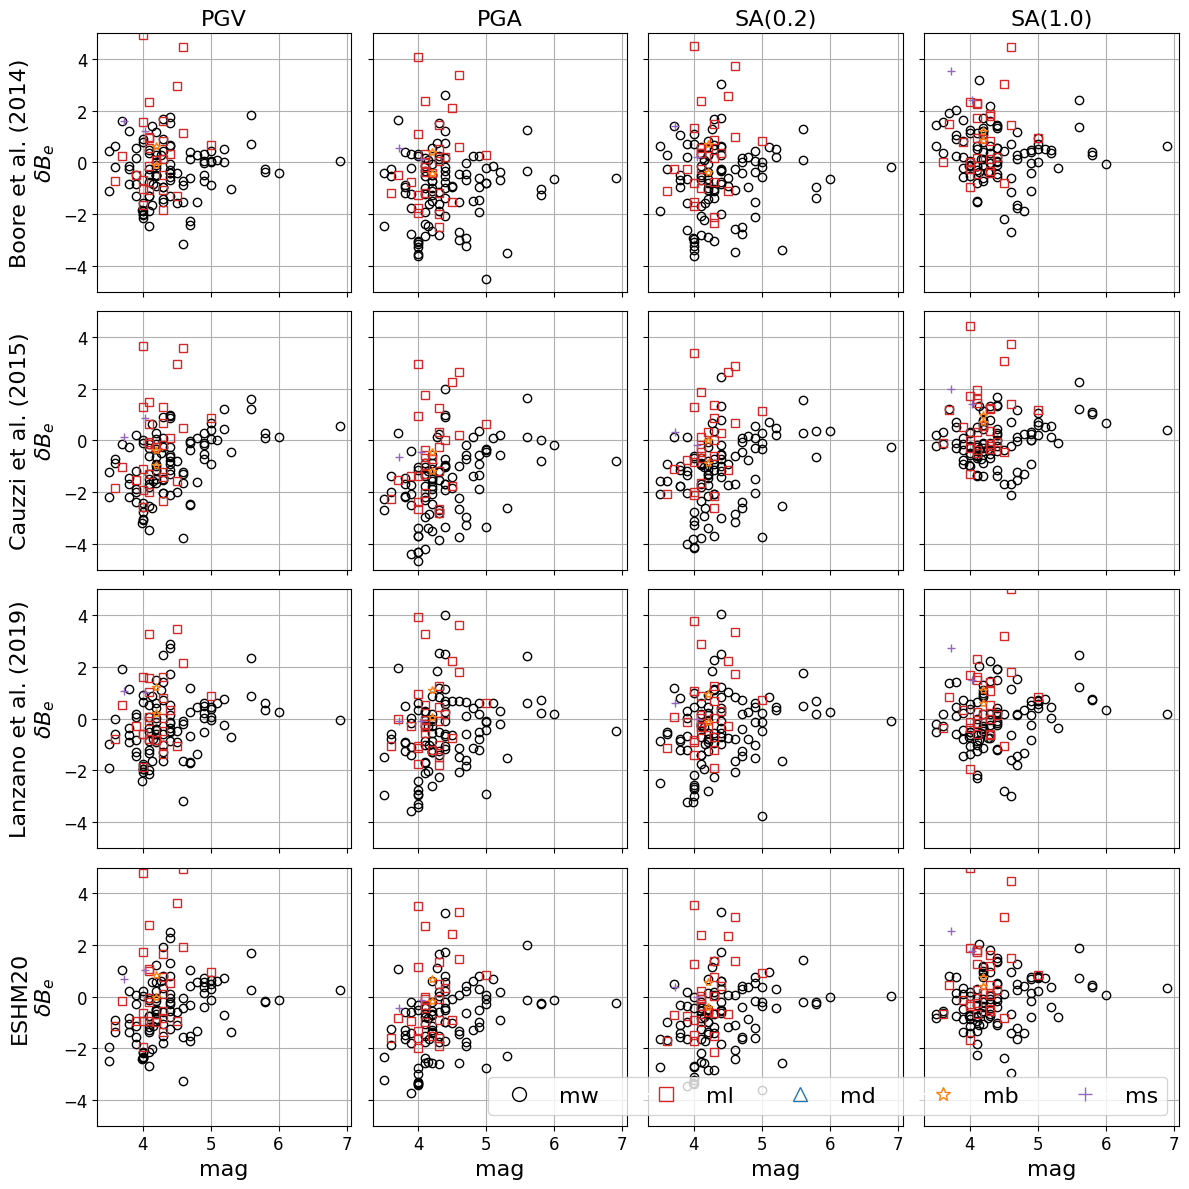

In [15]:
selected_imts = ["PGV", "PGA", "SA(0.2)", "SA(1.0)"]
fig, axs = plt.subplots(4, 4, figsize=(12,12), sharex=True, sharey=True)
predictor = "input rupture_parameter mag"

# Assign different markers and colours for each magnitude type
mag_markers_colors = {
    "mw": ("o", "k"),
    "ml": ("s", "tab:red"),
    "md": ("^", "tab:blue"),
    "mb": ("*", "tab:orange"),
    "ms": ("+", "tab:purple")
}

# Turn these into legend elements
legend_elements = [Line2D([0], [0], marker=m, color="w", label=n,mec=c, mfc="None", ms=10) 
                   for n, (m, c) in mag_markers_colors.items()]


for i, imt in enumerate(selected_imts):
    for j, gmm in enumerate(list(gmms)):
        # For each IMT and GMM get the inter-event residual
        gmm_id, gmm_col = gmms[gmm]
        predictand =  f"{imt} inter_event_residual {gmm}"
        xyvals = residuals_observations[["input rupture_parameter evt_id", 
                                         predictor, predictand,
                                         "input rupture_parameter mag_type"]].copy()
        xyvals.drop_duplicates("input rupture_parameter evt_id", inplace=True)
        # Plot each magnitude type with a different colour and marker
        for mtype, (mkr, mcol) in mag_markers_colors.items():
            xyvals_m = xyvals[xyvals["input rupture_parameter mag_type"] == mtype]
            axs[j, i].plot(xyvals_m[predictor], xyvals_m[predictand],
                           marker=mkr, ls="None", mec=mcol, mfc="None")
        axs[j, i].set_ylim(-5.0, 5.0)
        axs[j, i].grid(which="both")
        axs[j, i].tick_params(labelsize=12)
# Make things pretty
for i in range(4):
    gmm_id = gmms[list(gmms)[i]][0]
    axs[0, i].set_title(selected_imts[i], fontsize=16)
    axs[-1, i].set_xlabel(predictor.split()[-1], fontsize=16)
    axs[i, 0].set_ylabel(gmm_id + "\n" + r"$\delta B_e$" , fontsize=16)

fig.tight_layout()
axs[-1, -1].legend(handles=legend_elements, loc="lower right", ncol=5, fontsize=16)

The trends with magnitude are not obvious. The ML magnitudes do produce some outliers, which would ideally need to be corrected or discarded, but the trend towards negative residuals seems to be present in the Mw magnitudes too.

So the next question would be to look for spatial trends in the residuals. Now we want to produce a map of the residuals. Here we will show the events as a scatter plot over our basemap, which we can do because we added the event location information from the flatfile. 


Text(0.5, 0, '$\\delta B_e$')

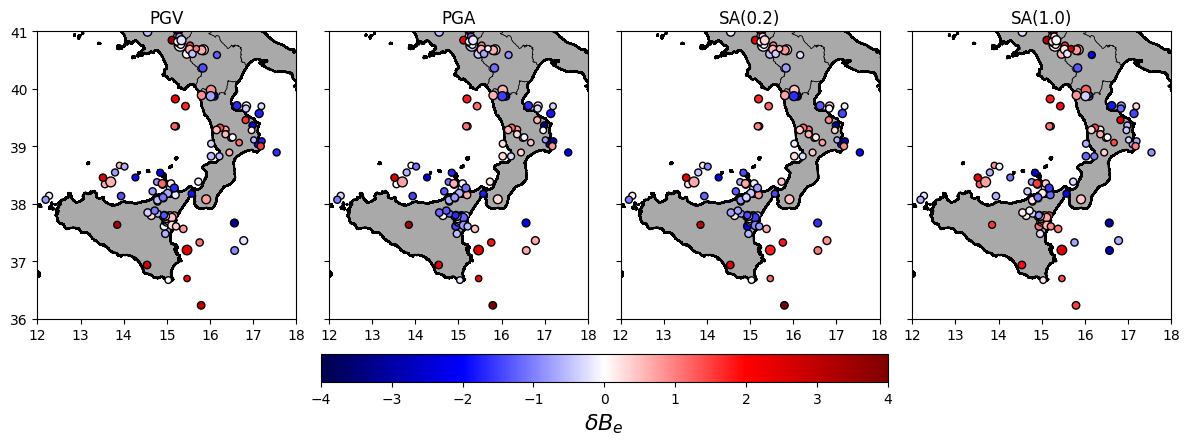

In [16]:

fig, axs = plt.subplots(1, 4, figsize=(12,12), sharex=True, sharey=True)
gmm = "LanzanoEtAl2019_RJB_OMO"
for i, imt in enumerate(selected_imts):
    axs[i] = ita1.plot(color="darkgrey", edgecolor="k", lw=0.5, ax=axs[i])
    axs[i] = ita0.plot(color="None", lw=1.5, ax=axs[i], )
    predictand = f"{imt} inter_event_residual {gmm}"
    vals = residuals_observations[
        [
            "input rupture_parameter evt_id",
            "input rupture_parameter evt_longitude",
            "input rupture_parameter evt_latitude",
            "input rupture_parameter mag",
            predictand
        ]
    ]
    vals.drop_duplicates("input rupture_parameter evt_id", inplace=True)
    cax = axs[i].scatter(vals["input rupture_parameter evt_longitude"],
                         vals["input rupture_parameter evt_latitude"],
                         c=vals[predictand], 
                         s=1.5 * vals["input rupture_parameter mag"] ** 2.0,
                         edgecolor="k",
                         cmap="seismic", norm=Normalize(-4.0, 4.0))
    axs[i].set_xlim(w, e)
    axs[i].set_ylim(s, n)
    axs[i].set_title(imt, fontsize=12)
fig.tight_layout()
cbar = fig.colorbar(cax, ax=axs, orientation="horizontal", shrink=0.5, pad=0.03)
cbar.ax.set_xlabel(r"$\delta B_e$", fontsize=16)

Here we see something interesting ... while the picture is quite variable overall, there is a clear cluster of negative residuals in northeastern Sicily. This aligns with the Etna volcano and the volcanic islands in the Tyrennhean Sea. Potentially the lower ground motions are being affected by volcanic events thatmight typically have lower stress drop and lower depth than tectonic events, which would affect the higher frequency motion more than longer period motion.

It's also possible that deeper events in this region are associated to the Calabrian Arc subduction, which would have a different ground motion scaling.

None of this is conclusive, but it would give some hints as to where to improve the data and what might influence the ground motion models for PSHA.

Take another look at the between-event residuals but this time with depth

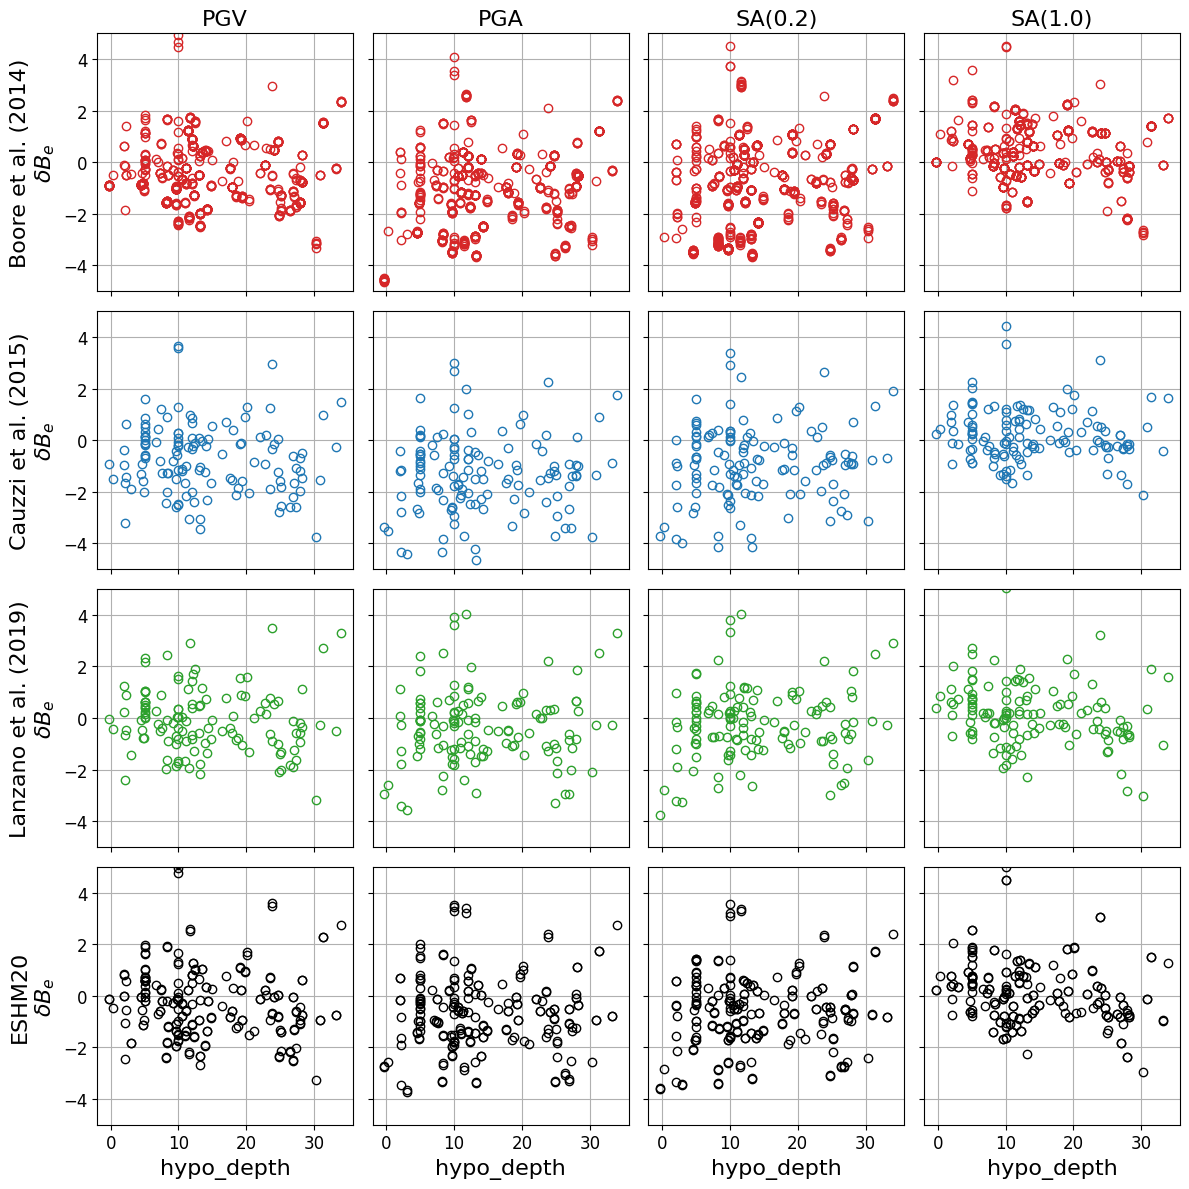

In [17]:
selected_imts = ["PGV", "PGA", "SA(0.2)", "SA(1.0)"]
fig, axs = plt.subplots(4, 4, figsize=(12,12), sharex=True, sharey=True)
predictor = "input rupture_parameter hypo_depth"
for i, imt in enumerate(selected_imts):
    for j, gmm in enumerate(list(gmms)):
        gmm_id, gmm_col = gmms[gmm]
        predictand =  f"{imt} inter_event_residual {gmm}"
        xyvals = residuals_observations[[predictor, predictand]].copy()
        xyvals.drop_duplicates(inplace=True)
        axs[j, i].plot(xyvals[predictor], xyvals[predictand], "o", mec=gmm_col, mfc="None")
        axs[j, i].set_ylim(-5.0, 5.0)
        axs[j, i].grid(which="both")
        axs[j, i].tick_params(labelsize=12)
for i in range(4):
    gmm_id = gmms[list(gmms)[i]][0]
    axs[0, i].set_title(selected_imts[i], fontsize=16)
    axs[-1, i].set_xlabel(predictor.split()[-1], fontsize=16)
    axs[i, 0].set_ylabel(gmm_id + "\n" + r"$\delta B_e$" , fontsize=16)
fig.tight_layout()

### Within-Event Residuals

The ranking metrics seemed to indicate that overall there were not too many systematic biases in the within-event residuals, at least for the Lanzano et al. (2019) and ESHM20 GMMs, which are calibrated more to Italy/Europe.

Let's look at the plots and verify this.

Here we will plot the trend of within-event residuals with distance to the ruptures. There is a lot of data, so to identify trends more clearly we will bin the observations every 25 km and plot the mean and standard deviation within each bin too.

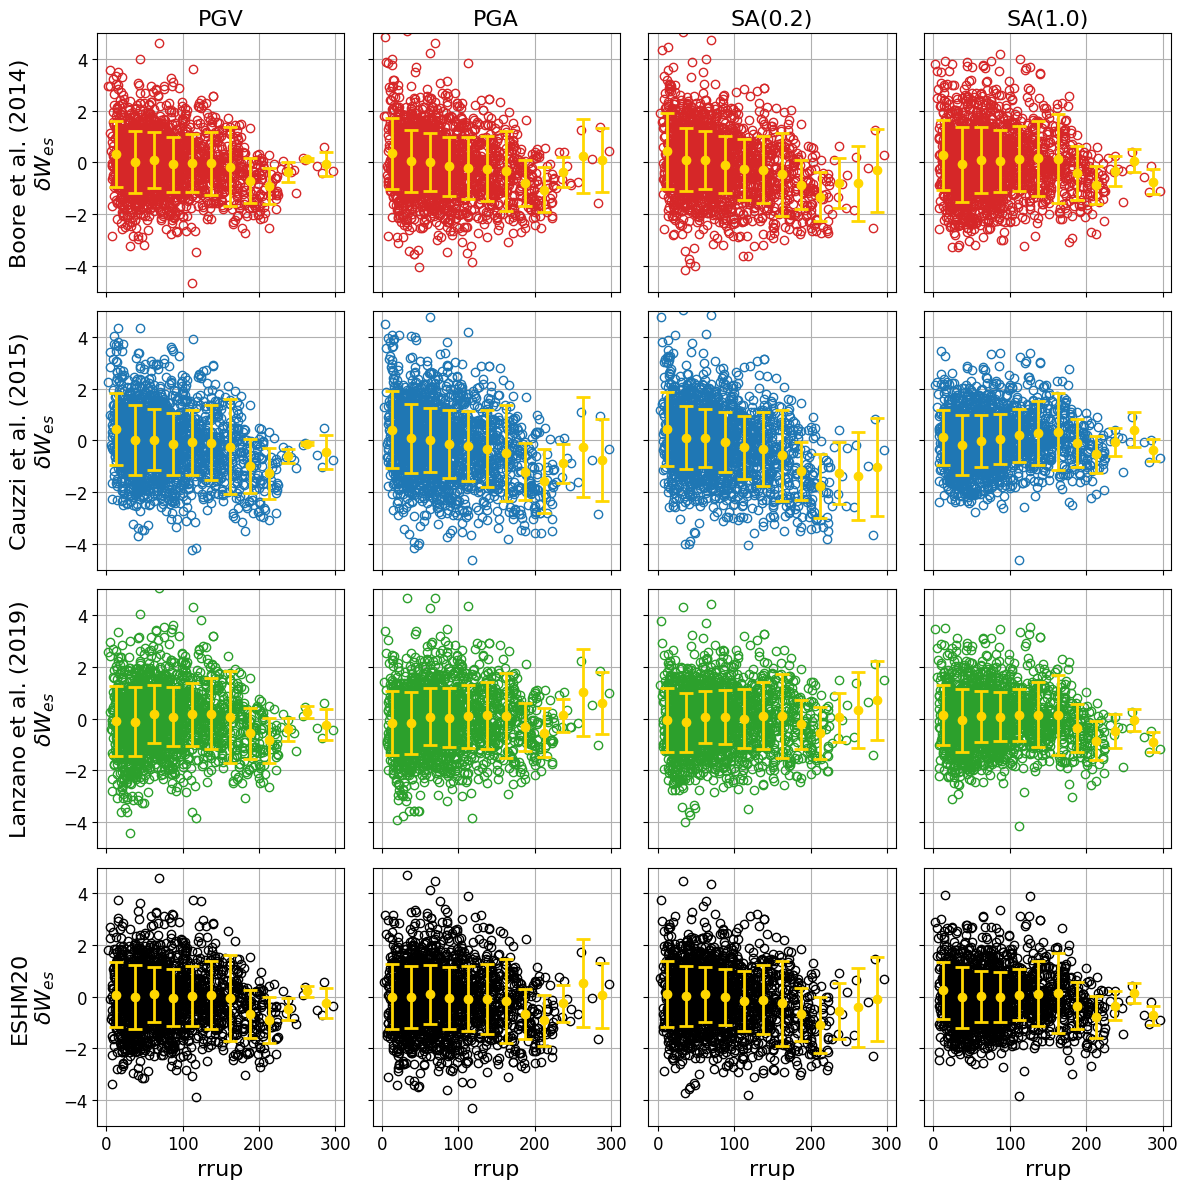

In [31]:
selected_imts = ["PGV", "PGA", "SA(0.2)", "SA(1.0)"]
fig, axs = plt.subplots(4, 4, figsize=(12,12), sharex=True, sharey=True)
predictor = "input distance_measure rrup"
distance_bins = np.arange(0, 325, 25)
for i, imt in enumerate(selected_imts):
    for j, gmm in enumerate(list(gmms)):
        gmm_id, gmm_col = gmms[gmm]
        predictand =  f"{imt} intra_event_residual {gmm}"
        xyvals = residuals_observations[[predictor, predictand]].copy()
        xyvals.drop_duplicates(inplace=True)
        xyvals["Distance Bin"] = pd.cut(xyvals["input distance_measure rrup"],
                                        bins=distance_bins)
        bin_stats = xyvals.groupby(
            "Distance Bin",
            observed=False
        )[predictand].agg(["mean", "std"]).reset_index()
        bin_stats["Bin Centre"] = bin_stats["Distance Bin"].apply(lambda x: x.mid).astype(float)
        axs[j, i].plot(xyvals[predictor], xyvals[predictand], "o", mec=gmm_col, mfc="None")
        axs[j, i].errorbar(
            bin_stats["Bin Centre"], 
            bin_stats["mean"],
            yerr=bin_stats["std"],
            fmt='o', color='gold', linewidth=2, 
            capsize=5, capthick=2, markersize=6,)
        axs[j, i].set_ylim(-5.0, 5.0)
        axs[j, i].grid(which="both")
        axs[j, i].tick_params(labelsize=12)
for i in range(4):
    gmm_id = gmms[list(gmms)[i]][0]
    axs[0, i].set_title(selected_imts[i], fontsize=16)
    axs[-1, i].set_xlabel(predictor.split()[-1], fontsize=16)
    axs[i, 0].set_ylabel(gmm_id + "\n" + r"$\delta W_{es}$" , fontsize=16)
fig.tight_layout()

Here we see that there is trend toward negative residuals at longer distances for the Boore et al. (2014) and Cauzzi et al. (2015) GMMs, which is less visible in the Lanzano et al. (2019) and ESHM20 GMMs. This indicates that the observed ground motions are attenuating faster than the Boore and the Cauzzi GMMs, but are generally well captured by the Italian and European models.

The variability in the normalised within-event residuals is higher than 1.0, indicating a greater path and site variability than that predicted by the models. 

### Station-to-Station Residuals

We have seen previously that the ground motion residuals can be separated into between-event and within-event components. For many sites here, however, we have multiple recordings. This allows us to separate out the within-event variability into a site-to-site component $\delta S2S_S$ and a site-corrected within-event variability. $\delta S2S_S$ is a normally distributed variate with a mean of 0 and a standard deviation of $\phi_{S2S}$. The $\delta S2S_S$ term indicates how much the expected ground motions at a given site are higher or lower than the average across all sites. If known, this part of the variability can be removed  This can be useful for site-specific probabilistic seismic hazard analysis, where repeated observations at a location can be used to constrain $\delta S2S_S$ and thus be removed from the total variability.

eGSIM does not calculate $\delta S2S_S$ directly and as most GMMs do not include their own estimates of $\phi_{S2S}$ then it cannot easily be determined in normalized form. However, we can make an estimate of the mean and variability of $\delta S2S_S$ for each station through a _frequentist_ interpretation, where:

$\delta S2S_S = \frac{1}{N_{REC}}\sum_i^{N_{REC}}{\delta W_{ES}}$

Firstly, how many records are there for each each station?

In [32]:
station_counts = residuals_observations.value_counts(["input site_parameter network",
                                                      "input site_parameter station"])
for sid, count in zip(station_counts.index, station_counts.to_numpy()):
    print(f"{sid} = {count}")

('IV', 'EVRN') = 32
('IT', 'TOR') = 31
('IT', 'PTT') = 31
('IV', 'PLAC') = 30
('IV', 'JOPP') = 29
('MN', 'CEL') = 28
('IV', 'CELI') = 26
('IV', 'SERS') = 25
('IV', 'EPOZ') = 25
('MN', 'TIP') = 23
('IT', 'RCU') = 23
('IT', 'SGV') = 23
('MN', 'CUC') = 22
('IV', 'CAR1') = 21
('IV', 'SSY') = 20
('IT', 'MSR') = 19
('IT', 'SPS') = 19
('IT', 'BNT') = 19
('IT', 'FDF') = 18
('IT', 'SRT') = 18
('IT', 'SVN') = 18
('IV', 'ACER') = 17
('IT', 'COR') = 17
('IT', 'RSN') = 17
('IT', 'SMA') = 17
('IT', 'TPA') = 17
('IT', 'LNT') = 17
('IT', 'MZZ') = 17
('IT', 'ACR') = 17
('IT', 'NAS') = 17
('IV', 'HVZN') = 16
('IV', 'PIPA') = 16
('IT', 'PLT') = 16
('IT', 'VZZ') = 16
('IT', 'CTZ') = 15
('IT', 'LMZ') = 15
('IT', 'SDN') = 15
('IT', 'SLL') = 15
('IT', 'PPL1') = 15
('IT', 'NTE') = 15
('IV', 'EMCN') = 15
('IV', 'ECHR') = 14
('IV', 'BULG') = 14
('IV', 'SALB') = 14
('IT', 'AMN') = 14
('IT', 'COS') = 14
('IT', 'NCH') = 14
('IT', 'GEA') = 14
('IT', 'PNI') = 14
('IT', 'MFG') = 14
('IV', 'IVPL') = 13
('IV', 'MRLC') 

To calculate $\delta S2S_S$ we will need the within-event residuals in _non-normalized_ format. So let's make a new query and then directly add on the information from the flatfile as we did previously. This second step is important because we will need the site ID's and locations of the stations.

In [33]:
residuals_observations = get_residuals_from_egsim(
    "./SItaly_egsim_flatfile.csv",  # Path to the flatfile
    gmms=list(gmms),  #
    imts=imts,
    query_string="(rrup <= 300.0) & (mag >= 3.5) & (evt_depth <= 35.0)",
    normalize=False, # This time do not normalize!
)
# Add on additional event parameters
for evt_col in ["evt_datetime", "evt_longitude", "evt_latitude", "mag_type"]:
    residuals_observations[f"input rupture_parameter {evt_col}"] = flatfile[evt_col].loc[residuals_observations.index]
for site_col in ["site_id", "network", "station", "location", "instrument",
                 "station_longitude", "station_latitude", "station_elevation"]:
    residuals_observations[f"input site_parameter {site_col}"] = flatfile[site_col].loc[residuals_observations.index]
residuals_observations

200


,PGA total_residual BooreEtAl2014,PGA total_residual CauzziEtAl2014,PGA total_residual KothaEtAl2020ESHM20,PGA total_residual LanzanoEtAl2019_RJB_OMO,PGA inter_event_residual BooreEtAl2014,PGA inter_event_residual CauzziEtAl2014,PGA inter_event_residual KothaEtAl2020ESHM20,PGA inter_event_residual LanzanoEtAl2019_RJB_OMO,PGA intra_event_residual BooreEtAl2014,PGA intra_event_residual CauzziEtAl2014,...,input rupture_parameter evt_datetime,input rupture_parameter evt_longitude,input rupture_parameter evt_latitude,input rupture_parameter mag_type,input site_parameter site_id,input site_parameter network,input site_parameter station,input site_parameter location,input site_parameter instrument,input site_parameter station_elevation
352,-0.909107,-1.698258,-0.669113,-0.035236,-0.745547,-1.404425,-0.787717,-0.511853,-0.163560,-0.293834,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.CAR1..HN,IV,CAR1,NaN,HN,680.0
353,-1.790188,-2.009129,-1.785298,-1.929401,-0.785103,-1.404425,-0.787717,-0.511853,-1.005085,-0.604704,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.ECHR..HN,IV,ECHR,NaN,HN,1168.0
354,-1.353754,-1.801942,-1.377379,-1.337600,-0.785103,-1.404425,-0.787717,-0.511853,-0.568651,-0.397518,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.ENIC..HN,IV,ENIC,NaN,HN,877.0
355,-1.341816,-1.809864,-1.369930,-1.313855,-0.785103,-1.404425,-0.787717,-0.511853,-0.556713,-0.405440,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.EVRN..HN,IV,EVRN,NaN,HN,421.0
356,-0.671388,-1.391730,-0.650274,-0.215724,-0.785103,-1.404425,-0.787717,-0.511853,0.113715,0.012694,...,2011-05-06T15:12:35.000000,14.943,37.804,mw,IV.HVZN..HN,IV,HVZN,NaN,HN,787.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,-1.947538,-2.634935,-1.858179,-1.375186,-0.755447,-1.316793,-0.880065,-0.638324,-1.192091,-1.318142,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,IV.SALB..HN,IV,SALB,NaN,HN,1200.0
623,-2.226741,-2.801078,-2.194242,-1.797153,-0.764572,-1.316793,-0.880065,-0.638324,-1.462169,-1.484285,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,IV.SERS..HN,IV,SERS,NaN,HN,1221.0
624,-0.072257,-0.939623,-0.517211,-0.349173,-0.769502,-1.316793,-0.880065,-0.638324,0.697245,0.377171,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,MN.CEL..HN,MN,CEL,NaN,HN,702.0
625,-1.293268,-2.095256,-1.349399,-0.794133,-0.755149,-1.316793,-0.880065,-0.638324,-0.538119,-0.778463,...,2013-12-23T04:20:38.000000,15.573,38.175,ml,MN.CUC..HN,MN,CUC,NaN,HN,637.0


As we are just looking at the stations, we can create a smaller dataframe with just the station  and the within-event residuals.

In [38]:
# Select just the within-event residuals and the site predictors
selection_columns = [
    'input site_parameter site_id',
    'input site_parameter vs30',
    'input site_parameter vs30measured',
    'input site_parameter station_longitude',
    'input site_parameter station_latitude',
    ]

for col in residuals_observations.columns:
    if ("intra_event_residual" in col) and (("PGA" in col) or ("PGV" in col) or ("SA(" in col)):
        selection_columns.append(col)
dwes = residuals_observations[selection_columns]
dwes

,input site_parameter site_id,input site_parameter vs30,input site_parameter vs30measured,input site_parameter station_longitude,input site_parameter station_latitude,PGA intra_event_residual BooreEtAl2014,PGA intra_event_residual CauzziEtAl2014,PGA intra_event_residual KothaEtAl2020ESHM20,PGA intra_event_residual LanzanoEtAl2019_RJB_OMO,PGV intra_event_residual BooreEtAl2014,...,SA(1.0) intra_event_residual KothaEtAl2020ESHM20,SA(1.0) intra_event_residual LanzanoEtAl2019_RJB_OMO,SA(2.0) intra_event_residual BooreEtAl2014,SA(2.0) intra_event_residual CauzziEtAl2014,SA(2.0) intra_event_residual KothaEtAl2020ESHM20,SA(2.0) intra_event_residual LanzanoEtAl2019_RJB_OMO,SA(3.0) intra_event_residual BooreEtAl2014,SA(3.0) intra_event_residual CauzziEtAl2014,SA(3.0) intra_event_residual KothaEtAl2020ESHM20,SA(3.0) intra_event_residual LanzanoEtAl2019_RJB_OMO
352,IV.CAR1..HN,620.0,False,16.2114,39.2534,-0.163560,-0.293834,0.118604,0.476616,-0.443188,...,-0.224358,-0.234923,-0.563557,-0.171052,-0.556171,-0.527058,-0.699115,-0.395713,-0.687581,-0.656637
353,IV.ECHR..HN,592.0,False,14.9129,37.6863,-1.005085,-0.604704,-0.997581,-1.417548,-0.968085,...,-0.501915,-0.814245,-0.368211,-0.255778,-0.253447,-0.569803,-0.342849,-0.200376,-0.247682,-0.571129
354,IV.ENIC..HN,546.0,False,15.0216,37.6314,-0.568651,-0.397518,-0.589662,-0.825747,-0.737048,...,-1.055479,-1.203050,-1.024168,-1.104563,-0.988168,-1.150456,-1.089026,-1.146844,-1.065627,-1.228715
355,IV.EVRN..HN,554.0,False,15.1356,37.6892,-0.556713,-0.405440,-0.582213,-0.802002,-0.529260,...,-0.566582,-0.698974,-0.664714,-0.761815,-0.643190,-0.791042,-0.522480,-0.599510,-0.513350,-0.662087
356,IV.HVZN..HN,872.0,False,14.7155,37.1783,0.113715,0.012694,0.137443,0.296129,0.448916,...,0.564354,0.708489,0.687149,0.510461,0.417947,0.539692,0.689597,0.438763,0.408228,0.520663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
622,IV.SALB..HN,845.0,False,16.3459,39.8772,-1.192091,-1.318142,-0.978114,-0.736862,-1.326078,...,-1.184936,-1.199243,-1.359096,-0.942054,-1.439474,-1.393508,-1.138034,-0.828736,-1.211106,-1.140104
623,IV.SERS..HN,923.0,False,16.6886,39.0359,-1.462169,-1.484285,-1.314177,-1.158829,-1.054712,...,-0.812850,-0.735259,-0.403272,-0.250201,-0.604182,-0.507515,-0.391028,-0.336154,-0.592811,-0.474649
624,MN.CEL..HN,1125.0,False,15.8939,38.2603,0.697245,0.377171,0.362854,0.289151,0.359052,...,-0.559321,-0.467989,-0.231191,-0.676379,-0.530309,-0.442220,-0.129365,-0.490792,-0.361641,-0.254002
625,MN.CUC..HN,1227.0,False,15.8155,39.9938,-0.538119,-0.778463,-0.469334,-0.155809,-0.453378,...,-0.180288,-0.081769,-0.711848,-0.175597,-0.819612,-0.650977,-0.707597,-0.212681,-0.721194,-0.539079


Now we can use Pandas to retreive group the observations by the station ID and return the mean and standard deviation of the within-event residuals for each station, and number of observations

In [47]:
# Frequentist interpretation where dS2Ss is the mean of dWes for a given station
# Group the within event residuals by station ID an apply the "mean" operation to the group
ds2s = dwes.groupby("input site_parameter site_id").agg(["mean", "std", "count"])
#ds2s_std = dwes.groupby("input site_parameter site_id", observed=False).agg("std")
# Now re-name the "intra_event_residual" to "dS2Ss" in the columns
column_mapping = dict([
    ((orig[0], orig[1]), (orig[0].replace("intra_event_residual", "dS2Ss"), orig[1]))
    for orig in ds2s.columns
])

column_mapping = dict([
    (orig[0], orig[0].replace("intra_event_residual", "dS2Ss"))
    for orig in ds2s.columns
])
ds2s.rename(columns=column_mapping, inplace=True, level=0)
ds2s

input site_parameter vs30             \
                                                  mean  std count   
input site_parameter site_id                                        
1V.ACC7.00.HN                                    826.0  NaN     1   
1V.AGR7.00.HN                                    484.0  NaN     1   
1V.ANZ7.00.HN                                    939.0  0.0     3   
1V.AVIG.00.HN                                    763.0  NaN     1   
1V.CGVT.00.HN                                    235.0  NaN     1   
...                                                ...  ...   ...   
XE.T0702..HN                                     787.0  0.0     4   
XE.TNOVA..HN                                     860.0  0.0     4   
XE.ZIDIL..HN                                     593.0  0.0     7   
XK.ALB1..HN                                      890.0  0.0     3   
XK.SELL..HN                                     1086.0  0.0     2   

                             input site_parameter vs30measured             \
                                                          mean  std count   
input site_parameter site_id                                                
1V.ACC7.00.HN                                              0.0  NaN     1   
1V.AGR7.00.HN                                              0.0  NaN     1   
1V.ANZ7.00.HN                                              0.0  0.0     3   
1V.AVIG.00.HN                                              0.0  NaN     1   
1V.CGVT.00.HN                                              1.0  NaN     1   
...                                                        ...  ...   ...   
XE.T0702..HN                                               0.0  0.0     4   
XE.TNOVA..HN                                               0.0  0.0     4   
XE.ZIDIL..HN                                               0.0  0.0     7   
XK.ALB1..HN                                                0.0  0.0     3   
XK.SELL..HN                                                0.0  0.0     2   

                             input site_parameter station_longitude       \
                                                               mean  std   
input site_parameter site_id                                               
1V.ACC7.00.HN                                             16.156890  NaN   
1V.AGR7.00.HN                                             15.828290  NaN   
1V.ANZ7.00.HN                                             15.925060  0.0   
1V.AVIG.00.HN                                             15.719390  NaN   
1V.CGVT.00.HN                                             15.855860  NaN   
...                                                             ...  ...   
XE.T0702..HN                                              16.083500  0.0   
XE.TNOVA..HN                                              16.261100  0.0   
XE.ZIDIL..HN                                              16.259630  0.0   
XK.ALB1..HN                                               16.597370  0.0   
XK.SELL..HN                                               16.627906  0.0   

                                   input site_parameter station_latitude  ...  \
                             count                                  mean  ...   
input site_parameter site_id                                              ...   
1V.ACC7.00.HN                    1                             40.491310  ...   
1V.AGR7.00.HN                    1                             40.356460  ...   
1V.ANZ7.00.HN                    3                             40.516010  ...   
1V.AVIG.00.HN                    1                             40.730740  ...   
1V.CGVT.00.HN                    1                             40.644820  ...   
...                            ...                                   ...  ...   
XE.T0702..HN                     4                             39.720900  ...   
XE.TNOVA..HN                     4                             39.974700  ...   
XE.ZIDIL..HN               

Now we can plot the variation in $\delta S2S_S$ with respect to, for example, $V_{S30}$ as a predictor. Here we do this for each GMM and bin the observations every 100 m/s to plot the mean and standard deviation of $\delta S2S_S$ for each bin. 

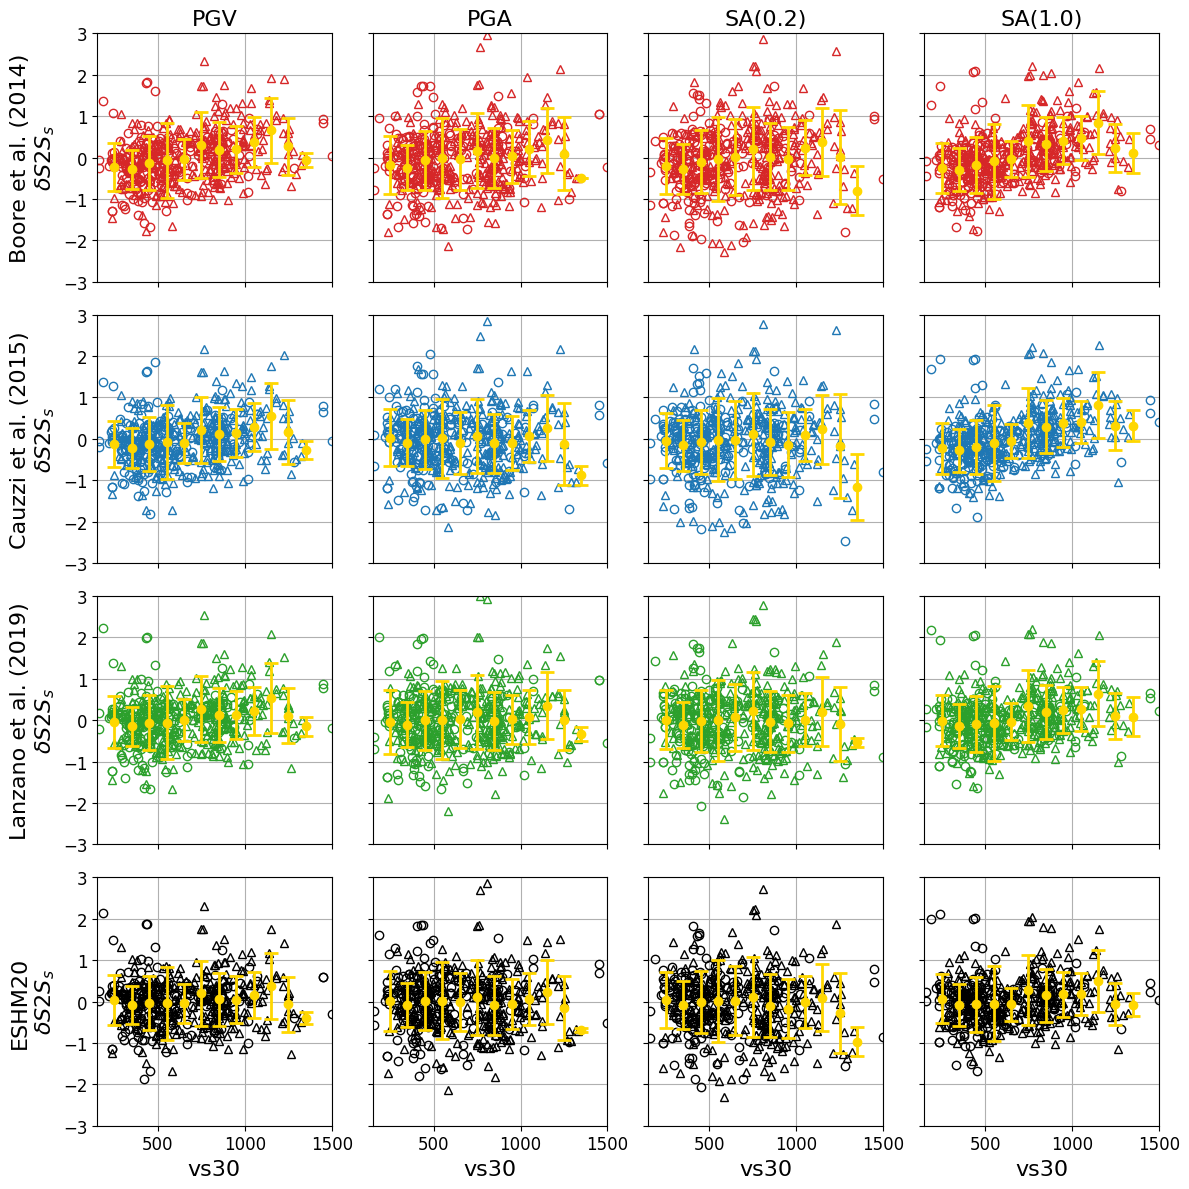

In [63]:
selected_imts = ["PGV", "PGA", "SA(0.2)", "SA(1.0)"]
fig, axs = plt.subplots(4, 4, figsize=(12,12), sharex=True, sharey=True)
predictor = "input site_parameter vs30"
additional = "input site_parameter vs30measured"
vs30_bins = np.arange(200, 1500, 100)
for i, imt in enumerate(selected_imts):
    for j, gmm in enumerate(list(gmms)):
        gmm_id, gmm_col = gmms[gmm]
        predictand =  f"{imt} dS2Ss {gmm}"
        xyvals = ds2s[[predictor, additional, predictand]].copy()
        xyvals["Vs30 Bin"] = pd.cut(xyvals["input site_parameter vs30"]["mean"],
                                    bins=vs30_bins)
        bin_stats = xyvals.groupby(
            "Vs30 Bin",
            observed=False
        )[predictand].agg(["mean", "std"]).reset_index()
        bin_stats["Bin Centre"] = bin_stats["Vs30 Bin"].apply(lambda x: x.mid).astype(float)
        idx = xyvals[additional]["mean"].astype(bool)
        axs[j, i].plot(xyvals[predictor]["mean"][idx], xyvals[predictand]["mean"][idx], "o", mec=gmm_col)
        axs[j, i].plot(xyvals[predictor]["mean"][~idx], xyvals[predictand]["mean"][~idx], "^", mec=gmm_col, mfc="None")
        axs[j, i].errorbar(
            bin_stats["Bin Centre"], 
            bin_stats[predictand]["mean"]["mean"],
            yerr=bin_stats[predictand]["mean"]["std"],
            fmt='o', color='gold', linewidth=2, 
            capsize=5, capthick=2, markersize=6,
        )
        axs[j, i].set_ylim(-3.0, 3.0)
        axs[j, i].set_xlim(150.0, 1500.0)
        axs[j, i].grid(which="both")
        axs[j, i].tick_params(labelsize=12)
for i in range(4):
    gmm_id = gmms[list(gmms)[i]][0]
    axs[0, i].set_title(selected_imts[i], fontsize=16)
    axs[-1, i].set_xlabel(predictor.split()[-1], fontsize=16)
    axs[i, 0].set_ylabel(gmm_id + "\n" + r"$\delta S2S_s$" , fontsize=16)
fig.tight_layout()

This plot shows that for the shorter period motion all four of the GMMs are largely unbiased with respect to the site term, meaning that they may be captuing the linear site scaling well. A linear trend can be seen in the Boore et al. (2014) and Cauzzi et al. (2015) GMMs, indicating some bias in those models, but this is not significant for the Lanzano et al. (2019) and ESHM20 GMMs. Most observations are low amplitude, so soil nonlinearity is not expected to have a major influence here.

Finally, we can look at the spatial trends in $\delta S2S_S$, which we will show below for just the Lanzano et al. (2019) GMM. Here we use separate markers for stations with a measured $V_{S30}$ (circle) and those with an inferred $V_{S30}$ (square).

Text(0.5, 0, '$\\delta S2S_S$')

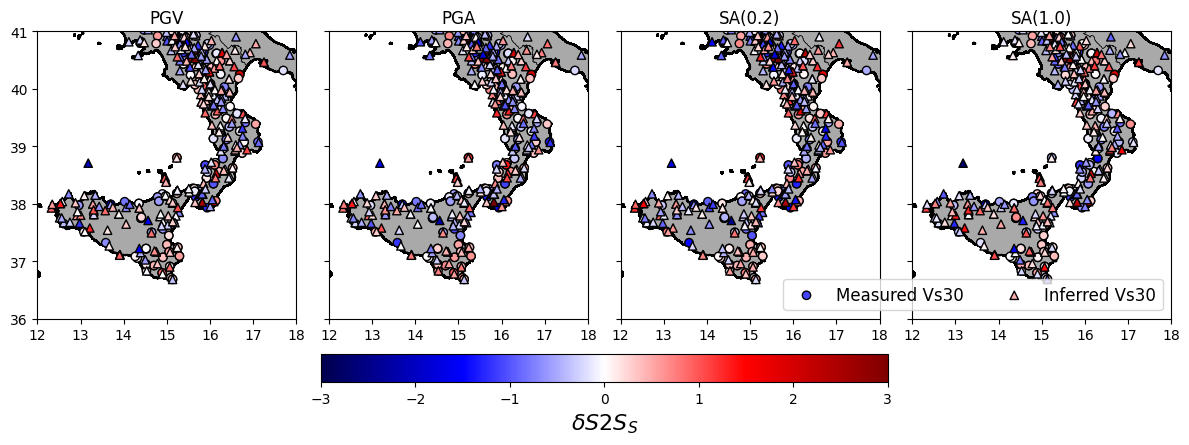

In [74]:
fig, axs = plt.subplots(1, 4, figsize=(12,12), sharex=True, sharey=True)
gmm = "LanzanoEtAl2019_RJB_OMO"
for i, imt in enumerate(selected_imts):
    axs[i] = ita1.plot(color="darkgrey", edgecolor="k", lw=0.5, ax=axs[i])
    axs[i] = ita0.plot(color="None", lw=1.5, ax=axs[i], )
    predictand = f"{imt} dS2Ss {gmm}"
    vals = ds2s[
        [
            "input site_parameter vs30",
            "input site_parameter vs30measured",
            "input site_parameter station_longitude",
            "input site_parameter station_latitude",
            predictand
        ]
    ]
    idx = vals["input site_parameter vs30measured"]["mean"].astype(bool)
    cax = axs[i].scatter(vals["input site_parameter station_longitude"]["mean"][idx],
                         vals["input site_parameter station_latitude"]["mean"][idx],
                         c=vals[predictand]["mean"][idx], 
                         marker="o", edgecolor="k",
                         cmap="seismic", norm=Normalize(-3.0, 3.0),
                         label="Measured Vs30")
    cax = axs[i].scatter(vals["input site_parameter station_longitude"]["mean"][~idx],
                         vals["input site_parameter station_latitude"]["mean"][~idx],
                         c=vals[predictand]["mean"][~idx], 
                         marker="^", edgecolor="k",
                         cmap="seismic", norm=Normalize(-3.0, 3.0),
                         label="Inferred Vs30")
    axs[i].set_xlim(w, e)
    axs[i].set_ylim(s, n)
    axs[i].set_title(imt, fontsize=12)
fig.tight_layout()
axs[-1].legend(loc = "lower right", fontsize=12, ncol=2)
cbar = fig.colorbar(cax, ax=axs, orientation="horizontal", shrink=0.5, pad=0.03)
cbar.ax.set_xlabel(r"$\delta S2S_S$", fontsize=16)

In the map above, we can clearly see a lot of station-to-station variability, but there do appear to be some spatial trends and the pattern is not entirely random.
In ground motion modelling we can exploit these spatial trends to predict the source, path and site terms at any location given the spatially observed variables. 

This is _non-ergodic_ ground motion modelling ... and will be a topic for the future!